# Reference dataset construction: the nine-month merge rule

The baseline and complexity notebooks both hold the reference-dataset construction fixed and correct: every re-default is logged as its own independent observation, exactly matching what `estimate_formula_inputs` has always computed. This notebook checks whether that's actually the right thing to do.

EBA/GL/2017/16 §101 (implementing Article 52(b) of the RTS on IRB assessment methodology) requires that a re-default occurring within nine months of an exposure's return to non-defaulted status be treated as a continuation of the original default, not logged as a second independent observation, for the purpose of LGD estimation. Neither this project's own `dgp.py` nor the prior R implementation it's derived from applied that rule before now (see `docs/dgp_assumptions.md`, "Re-default independence: the nine-month merge rule"). Every re-default in the baseline and complexity notebooks was counted as independent regardless of timing, the naive treatment this notebook compares against the compliant one.

This is a check on how the reference dataset gets built, not on the data-generating process itself: the DGP stays exactly as specified in the baseline notebook throughout, correctly, in every cell below. That makes it a different question from misspecification, the next notebook's subject: whether the formula survives when the DGP's own assumptions are wrong.

In [1]:
import numpy as np

from lgd_sim.dgp import DGPParams
from lgd_sim.experiment import run_merge_compliance
from lgd_sim.metrics import summarize
from lgd_sim.plotting import plot_levels_regime_comparison, plot_regime_comparison

SEED = 42
N_EXPOSURES = 10_000
N_REPLICATIONS = 1_000
BASE_PARAMS = DGPParams(pc=0.2, prd=0.1)
RESULTS_DIR = "../results"

## Nine-month re-default merge rule

Both regimes simulate the exact same portfolio in a given replication; only how the reference dataset is built from it differs. Naive estimation counts every re-default as independent. Compliant estimation excludes a re-default from the cured and re-defaulted counts if it happened within nine months of curing, folding its whole cure-to-re-default episode into the same recovery-rate pool as a genuine first default instead.

The x-axis below is the merge fraction: the share of re-defaults that land under the nine-month threshold, computed directly from each replication's simulated exposures. `mean_cure_month` is swept to produce a range of merge fractions - a later mean cure month leaves less of the loan term remaining after cure, so more re-defaults land within nine months of it.

In [2]:
mean_cure_month_values = [1.0, 5.0, 10.0, 20.0, 30.0, 40.0, 50.0, 55.0, 60.0, 70.0, 80.0]

merge_results = run_merge_compliance(
    sweep_param="mean_cure_month",
    sweep_values=mean_cure_month_values,
    base_params=BASE_PARAMS,
    n_exposures=N_EXPOSURES,
    n_replications=N_REPLICATIONS,
    rng=np.random.default_rng(SEED),
)

merge_fraction_by_sweep = (
    merge_results[merge_results["regime"] == "naive"]
    .groupby("mean_cure_month")
    .apply(lambda g: g["n_merged"].sum() / g["n_redefault"].sum(), include_groups=False)
    .rename("merge_fraction")
    .reset_index()
)

naive_summary = summarize(
    merge_results[merge_results["regime"] == "naive"], sweep_param="mean_cure_month"
)
compliant_summary = summarize(
    merge_results[merge_results["regime"] == "compliant"], sweep_param="mean_cure_month"
)
naive_summary = naive_summary.merge(merge_fraction_by_sweep, on="mean_cure_month")
compliant_summary = compliant_summary.merge(merge_fraction_by_sweep, on="mean_cure_month")

naive_summary.to_csv(f"{RESULTS_DIR}/merge_naive_summary.csv", index=False)
compliant_summary.to_csv(f"{RESULTS_DIR}/merge_compliant_summary.csv", index=False)

error_mean_columns = ["mean_cure_month", "merge_fraction"] + [
    f"{f}_error_mean" for f in ["lgd_basic", "lgd_lgc", "lgd_prd", "lgd_new"]
]
naive_summary[error_mean_columns]

,mean_cure_month,merge_fraction,lgd_basic_error_mean,lgd_lgc_error_mean,lgd_prd_error_mean,lgd_new_error_mean
0,1.0,0.153489,-0.008744,0.004565,0.011166,7.680677e-06
1,5.0,0.164153,-0.007812,0.004680,0.011959,8.943547e-05
2,10.0,0.181272,-0.006956,0.004604,0.012967,-3.747834e-05
3,20.0,0.227809,-0.004857,0.004613,0.015014,-3.298481e-05
4,30.0,0.312566,-0.002882,0.004663,0.017133,-8.367541e-05
5,40.0,0.497405,-0.000561,0.004939,0.019354,1.614619e-04
6,50.0,0.803428,0.001091,0.004616,0.021065,-1.806956e-04
7,55.0,0.913411,0.002192,0.004929,0.022247,8.516805e-05
8,60.0,0.970076,0.002799,0.004966,0.022883,1.139727e-04
9,70.0,0.998356,0.003167,0.004870,0.023247,8.300652e-07


In [3]:
compliant_summary[error_mean_columns]

,mean_cure_month,merge_fraction,lgd_basic_error_mean,lgd_lgc_error_mean,lgd_prd_error_mean,lgd_new_error_mean
0,1.0,0.153489,-0.005888,0.003861,1.101421e-02,0.000008
1,5.0,0.164153,-0.005024,0.003938,1.154795e-02,0.000095
2,10.0,0.181272,-0.004230,0.003775,1.212654e-02,-0.000029
3,20.0,0.227809,-0.002394,0.003552,1.298853e-02,-0.000013
4,30.0,0.312566,-0.000830,0.003196,1.295745e-02,-0.000037
5,40.0,0.497405,0.000477,0.002552,1.049666e-02,0.000221
6,50.0,0.803428,0.000194,0.000797,4.117409e-03,-0.000087
7,55.0,0.913411,0.000243,0.000485,1.976254e-03,0.000097
8,60.0,0.970076,0.000159,0.000238,7.581023e-04,0.000104
9,70.0,0.998356,-0.000032,-0.000028,7.287728e-07,-0.000036


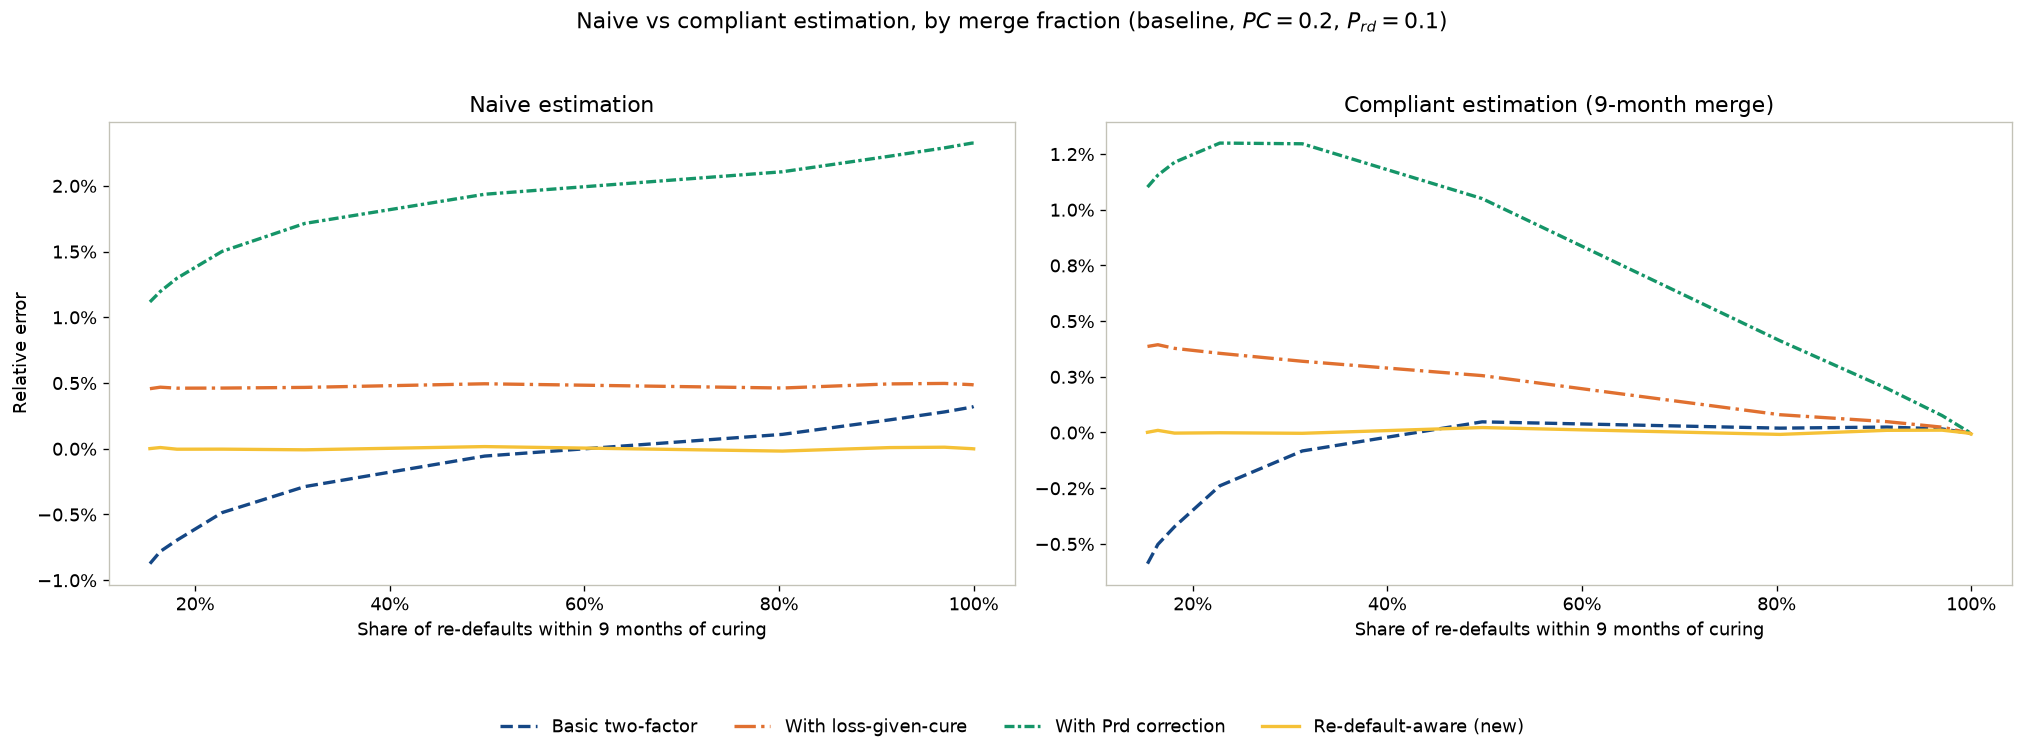

In [4]:
fig = plot_regime_comparison(
    naive_summary,
    compliant_summary,
    sweep_param="merge_fraction",
    x_label="Share of re-defaults within 9 months of curing",
    title="Naive vs compliant estimation, by merge fraction (baseline, $PC=0.2$, $P_{rd}=0.1$)",
    x_as_percent=True,
)
fig.savefig(f"{RESULTS_DIR}/merge_regime_comparison.png", bbox_inches="tight")

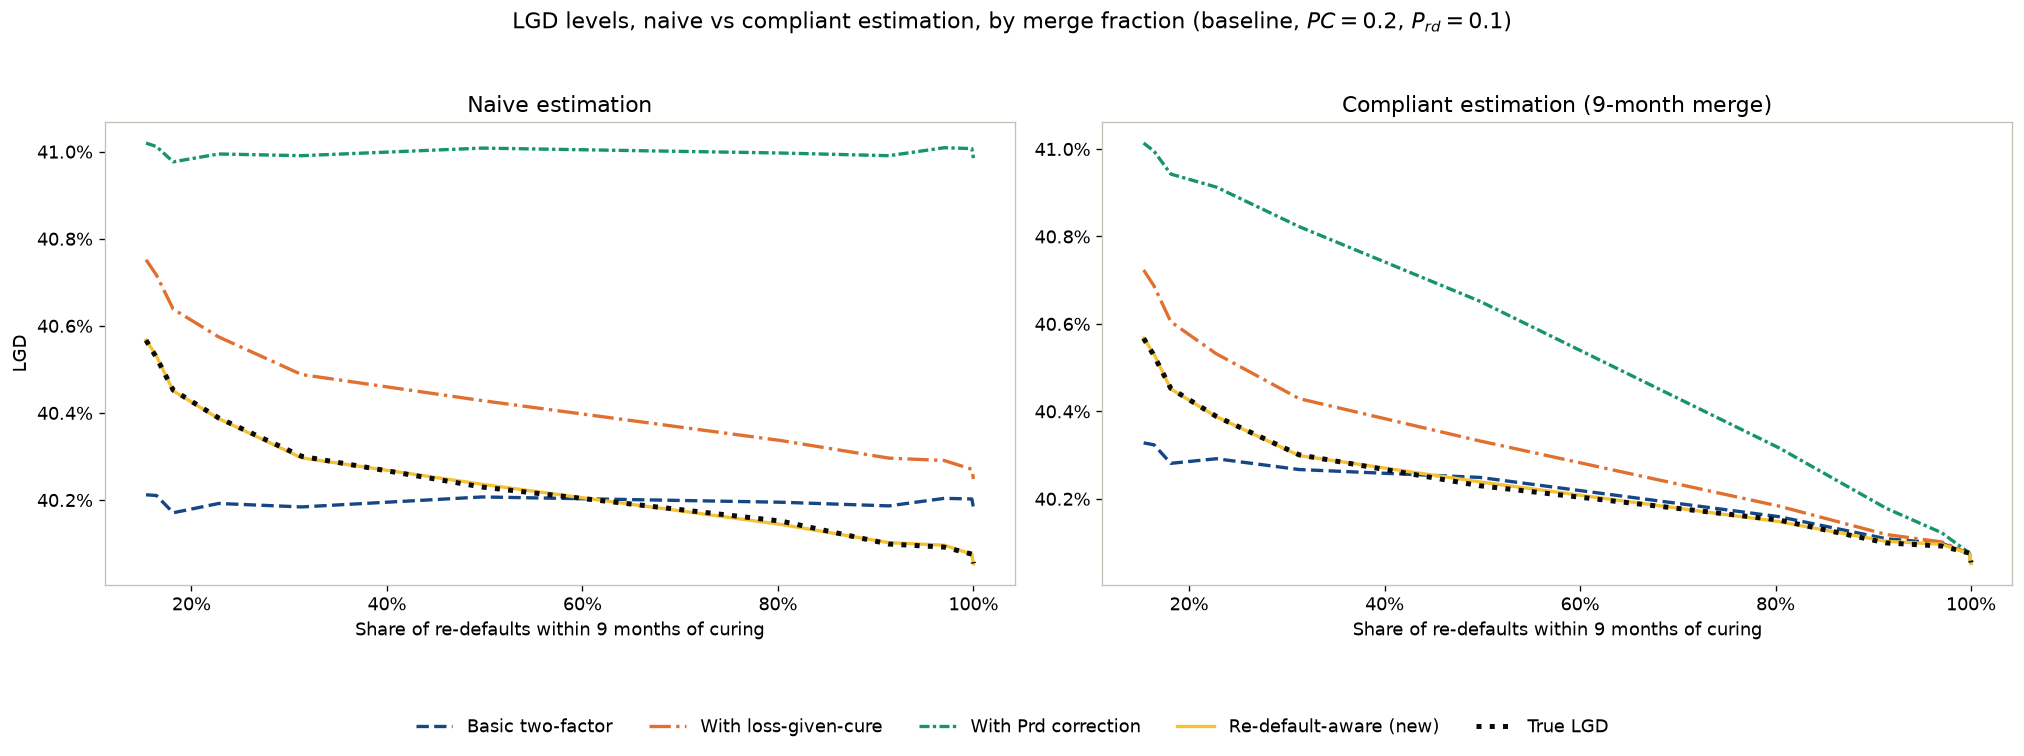

In [5]:
fig = plot_levels_regime_comparison(
    naive_summary,
    compliant_summary,
    sweep_param="merge_fraction",
    x_label="Share of re-defaults within 9 months of curing",
    title="LGD levels, naive vs compliant estimation, by merge fraction (baseline, $PC=0.2$, $P_{rd}=0.1$)",
    x_as_percent=True,
)
fig.savefig(f"{RESULTS_DIR}/merge_levels_comparison.png", bbox_inches="tight")

The compliant regime doesn't just shrink the naive formulas' bias, it changes its shape entirely, and the two panels tell almost opposite stories as the merge fraction climbs toward 100%. Under naive estimation, nothing converges: the basic formula's bias drifts from -0.87% up through zero to +0.32%, and the Prd-correction's bias climbs the whole way from +1.12% to +2.32%, growing worse as the merge fraction grows, because naive estimation never recognizes that there's less and less genuine independent re-default left to correct for.

Under compliant estimation, all four formulas converge to the same value, about -0.01%, as the merge fraction approaches 100%. That's not a coincidence: at a 100% merge fraction, compliant estimation correctly finds zero genuinely independent re-defaults left ($P_{rd}=0$ in its own estimate), and the algebraic identity from `derivation.md`, confirmed empirically in the complexity notebook, applies exactly, every formula collapses to the basic two-factor estimate when $P_{rd}=0$. The basic formula's compliant bias swings from -0.59% up through zero and levels off with the rest; the loss-given-cure formula's compliant bias falls fairly steadily toward the same point. The Prd-correction's compliant bias isn't monotonic: it still rises at first, from +1.10% up to a peak of about +1.30% around a 25-30% merge fraction, tracking naive's direction over that stretch, before turning and falling the rest of the way to convergence, unlike naive's version of the same formula, which never turns and keeps climbing throughout. The re-default-aware formula stays close to zero throughout both panels, the only formula that doesn't need the merge fraction to reach an extreme before it's already right.

### Where the residual bias comes from

The re-default-aware formula only has one slot for a recovery rate. Compliant estimation has to pool a merged exposure's whole cure-to-re-default recovery, $1-(1-RR_{brd})(1-RR_{ard})$, a compound of two components, into the same average used for a genuine first default's plain recovery draw. If those two populations have different average recovery, pooling them introduces a small mismatch. The next two cells check this directly on a configuration chosen to make the effect visible above sampling noise: a higher re-default probability and a late mean cure month, both of which push more re-defaults under the nine-month threshold.

In [6]:
STRESS_PARAMS = DGPParams(pc=0.2, prd=0.3, mean_cure_month=40.0)
STRESS_REPLICATIONS = 3_000

stress_results = run_merge_compliance(
    sweep_param="mean_cure_month",
    sweep_values=[STRESS_PARAMS.mean_cure_month],
    base_params=STRESS_PARAMS,
    n_exposures=N_EXPOSURES,
    n_replications=STRESS_REPLICATIONS,
    rng=np.random.default_rng(7),
)
stress_summary = summarize(stress_results, sweep_param="regime")
stress_summary[["regime", "lgd_new_error_mean", "lgd_new_error_sd", "n_replications"]]

,regime,lgd_new_error_mean,lgd_new_error_sd,n_replications
0,compliant,0.000696,0.002413,3000
1,naive,-0.000096,0.002662,3000


In [7]:
compliant_row = stress_summary[stress_summary["regime"] == "compliant"].iloc[0]
naive_row = stress_summary[stress_summary["regime"] == "naive"].iloc[0]
compliant_se = compliant_row["lgd_new_error_sd"] / STRESS_REPLICATIONS**0.5
naive_se = naive_row["lgd_new_error_sd"] / STRESS_REPLICATIONS**0.5

print(
    f"compliant lgd_new bias: {compliant_row['lgd_new_error_mean']:.4%}, "
    f"z = {compliant_row['lgd_new_error_mean'] / compliant_se:.1f}"
)
print(
    f"naive lgd_new bias: {naive_row['lgd_new_error_mean']:.4%}, "
    f"z = {naive_row['lgd_new_error_mean'] / naive_se:.1f}"
)

compliant lgd_new bias: 0.0696%, z = 15.8
naive lgd_new bias: -0.0096%, z = -2.0


In [8]:
from lgd_sim.dgp import simulate_portfolio

exposures = simulate_portfolio(STRESS_PARAMS, n=200_000, rng=np.random.default_rng(0))
cured = exposures["cured"].to_numpy()
redefaulted = exposures["redefaulted"].to_numpy()
merged = redefaulted & (exposures["t_rd"].to_numpy() < 9)
genuine = redefaulted & ~merged

rr_never_cured = exposures.loc[~cured, "rr"]
rr_effective_merged = 1 - (1 - exposures.loc[merged, "rr_before_redefault"]) * (
    1 - exposures.loc[merged, "rr_after_redefault"]
)
rr_after_genuine = exposures.loc[genuine, "rr_after_redefault"]

print(f"never-cured recovery:  n={len(rr_never_cured):>7,}  mean={rr_never_cured.mean():.4f}")
print(
    f"merged recovery:       n={len(rr_effective_merged):>7,}  mean={rr_effective_merged.mean():.4f}"
)
print(f"genuine re-default rr: n={len(rr_after_genuine):>7,}  mean={rr_after_genuine.mean():.4f}")

never-cured recovery:  n=159,832  mean=0.5002
merged recovery:       n=  6,078  mean=0.8610
genuine re-default rr: n=  5,958  mean=0.4946


At this stress configuration ($P_{rd}=0.3$, mean cure month 40, chosen to push a large share of re-defaults under the nine-month threshold), the residual is small but real: compliant estimation's `lgd_new` bias is +0.070% (z = 15.8, 3,000 replications), while naive's is -0.010% (z = -2.0, indistinguishable from zero). Compliant estimation removes a much larger bias than this on every other formula, but it isn't perfectly clean for the re-default-aware formula specifically.

The component breakdown explains why. A never-cured exposure's recovery averages 0.5002, matching the underlying $\text{Beta}(0.3, 0.3)$ draw. A genuinely independent re-default's fresh recovery averages 0.4946, the same distribution, which is exactly why naive pooling of these two groups doesn't bias the formula: they're the same thing statistically. A merged exposure's combined recovery, $1-(1-RR_{brd})(1-RR_{ard})$, averages 0.8610, far higher, because it compounds two positive recovery components (substantial accrued paydown by the time of merger, plus a fresh recovery on top of that) instead of drawing from a single distribution. Compliant estimation has nowhere else to put a merged exposure's recovery except into the same pool used for genuine first defaults, and that pool's mean shifts once it's diluted with something Beta(0.3, 0.3) never accounted for. Removing the naive treatment's much larger double-counting bias trades it for this smaller, structurally different one: a real bank applying this exact formula to a correctly-merged reference dataset would face the same tradeoff, since the formula has no fifth input to keep a merged exposure's compound recovery separate from a fresh one's.

This residual doesn't survive to a 100% merge fraction, though, where the main sweep above found all four formulas converging to the same near-zero bias: at that extreme every re-default is merged, so there's no genuine re-default population left for the pooling mismatch to bite on in the first place. It shows up specifically in the partial range, where some re-defaults are merged and some aren't, and the two populations' different recovery rates get pooled together.